In [1]:
import glob
import os

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
DRIVE_URL = '/content/drive/MyDrive/radar_base_general_aleman_ramirez'
LOCAL_PATH = os.getcwd()

In [3]:
def detect_environment():
    try:
        ipython_env = str(get_ipython())

        if 'google.colab' in ipython_env:
            return "Google Colab"
        elif 'zmqshell' in ipython_env:
            return "Jupyter Notebook Local"
        else:
            return "Terminal interactiva de Python"
    except NameError:
        return "Script de Python estándar (.py)"


print(f"Entorno detectado: {detect_environment()}")

Entorno detectado: Jupyter Notebook Local


In [4]:
if detect_environment() != "Google Colab":
    BASE = LOCAL_PATH
else:
    BASE = DRIVE_URL
    from google.colab import drive

    drive.mount('/content/drive')

In [5]:
SCALED = os.path.join(BASE, "scaled")
REGISTERED = os.path.join(BASE, "registered")
GT = os.path.join(BASE, "gt")
NOISY = os.path.join(BASE, "noisy")
GTRUTH = os.path.join(BASE, "gtruth")

for carpeta in [REGISTERED, GT, NOISY, GTRUTH]:
    os.makedirs(carpeta, exist_ok=True)

print("Carpetas listas:")
print("SCALED:", SCALED)
print("REGISTERED:", REGISTERED)
print("GT:", GT)
print("NOISY:", NOISY)
print("GTRUTH:", GTRUTH)

Carpetas listas:
SCALED: C:\Users\Sebastian-EDU\Documents\GitHub\ComputerVisionIA\CV_GuideThree\scaled
REGISTERED: C:\Users\Sebastian-EDU\Documents\GitHub\ComputerVisionIA\CV_GuideThree\registered
GT: C:\Users\Sebastian-EDU\Documents\GitHub\ComputerVisionIA\CV_GuideThree\gt
NOISY: C:\Users\Sebastian-EDU\Documents\GitHub\ComputerVisionIA\CV_GuideThree\noisy
GTRUTH: C:\Users\Sebastian-EDU\Documents\GitHub\ComputerVisionIA\CV_GuideThree\gtruth


In [6]:
def load_single_channel(path):
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    if img is None:
        raise ValueError(f"No se pudo leer: {path}")
    if len(img.shape) == 3:
        img = img[:, :, 0]
    return img


def calculate_mse(img1, img2):
    img1 = img1.astype(np.float64)
    img2 = img2.astype(np.float64)
    return np.mean((img1 - img2) ** 2)


def align_image_ecc(image, template, warp_mode=cv2.MOTION_AFFINE,
                    number_of_iterations=500, termination_eps=1e-6):
    """
    Registra una imagen respecto a una referencia usando ECC.
    """
    image_f = image.astype(np.float32) / 255.0
    template_f = template.astype(np.float32) / 255.0

    # Suavizado leve para ayudar al registro sobre imágenes SAR
    image_f = cv2.GaussianBlur(image_f, (5, 5), 0)
    template_f = cv2.GaussianBlur(template_f, (5, 5), 0)

    if warp_mode == cv2.MOTION_HOMOGRAPHY:
        warp_matrix = np.eye(3, 3, dtype=np.float32)
    else:
        warp_matrix = np.eye(2, 3, dtype=np.float32)

    criteria = (
        cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT,
        number_of_iterations,
        termination_eps
    )

    cc, warp_matrix = cv2.findTransformECC(
        template_f,
        image_f,
        warp_matrix,
        warp_mode,
        criteria,
        None,
        1
    )

    h, w = template.shape[:2]

    if warp_mode == cv2.MOTION_HOMOGRAPHY:
        aligned = cv2.warpPerspective(
            image,
            warp_matrix,
            (w, h),
            flags=cv2.INTER_LINEAR + cv2.WARP_INVERSE_MAP,
            borderMode=cv2.BORDER_CONSTANT,
            borderValue=0
        )
    else:
        aligned = cv2.warpAffine(
            image,
            warp_matrix,
            (w, h),
            flags=cv2.INTER_LINEAR + cv2.WARP_INVERSE_MAP,
            borderMode=cv2.BORDER_CONSTANT,
            borderValue=0
        )

    return aligned, warp_matrix, cc

In [7]:
scaled_files = sorted(glob.glob(os.path.join(SCALED, "*_scaled.tiff")))

print("Cantidad de imágenes no filtradas reescaladas:", len(scaled_files))
for i, path in enumerate(scaled_files, start=1):
    print(f"{i}. {os.path.basename(path)}")

Cantidad de imágenes no filtradas reescaladas: 10
1. 2016-06-14-00_00_2016-06-14-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled.tiff
2. 2016-07-08-00_00_2016-07-08-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled.tiff
3. 2016-07-20-00_00_2016-07-20-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled.tiff
4. 2016-07-26-00_00_2016-07-26-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled.tiff
5. 2016-08-01-00_00_2016-08-01-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled.tiff
6. 2016-08-13-00_00_2016-08-13-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled.tiff
7. 2016-08-19-00_00_2016-08-19-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled.tiff
8. 2016-08-25-00_00_2016-08-25-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled.tiff
9. 2016-09-06-00_00_2016-09-06-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled.tiff
10. 2016-09-12-00_00_2016-09-12-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled.tiff


Imagen de referencia:
2016-08-01-00_00_2016-08-01-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled.tiff
Shape: (2500, 1541)
Tipo: uint8
Máximo: 191
Promedio: 84.54038572355613
Mínimo: 6


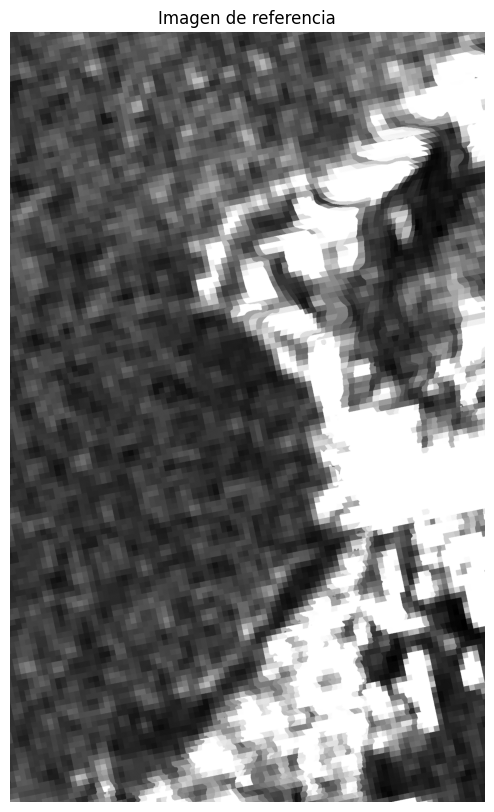

In [8]:
reference_name = "2016-08-01-00_00_2016-08-01-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled.tiff"
reference_path = os.path.join(SCALED, reference_name)

ref_img = load_single_channel(reference_path)

print("Imagen de referencia:")
print(reference_name)
print("Shape:", ref_img.shape)
print("Tipo:", ref_img.dtype)
print("Máximo:", np.max(ref_img))
print("Promedio:", np.mean(ref_img))
print("Mínimo:", np.min(ref_img))

plt.figure(figsize=(8, 10))
plt.imshow(ref_img, cmap="gray")
plt.title("Imagen de referencia")
plt.axis("off")
plt.show()

In [9]:
files_to_register = [p for p in scaled_files if os.path.basename(p) != reference_name]

print("Cantidad total:", len(scaled_files))
print("Referencia:", reference_name)
print("Cantidad a registrar:", len(files_to_register))
for i, path in enumerate(files_to_register, start=1):
    print(f"{i}. {os.path.basename(path)}")

Cantidad total: 10
Referencia: 2016-08-01-00_00_2016-08-01-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled.tiff
Cantidad a registrar: 9
1. 2016-06-14-00_00_2016-06-14-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled.tiff
2. 2016-07-08-00_00_2016-07-08-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled.tiff
3. 2016-07-20-00_00_2016-07-20-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled.tiff
4. 2016-07-26-00_00_2016-07-26-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled.tiff
5. 2016-08-13-00_00_2016-08-13-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled.tiff
6. 2016-08-19-00_00_2016-08-19-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled.tiff
7. 2016-08-25-00_00_2016-08-25-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled.tiff
8. 2016-09-06-00_00_2016-09-06-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled.tiff
9. 2016-09-12-00_00_2016-09-12-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled.tiff


In [10]:
# Limpiar registros previos y copiar la referencia a la carpeta REGISTERED
for path in glob.glob(os.path.join(REGISTERED, "*_registered.tiff")):
    os.remove(path)

registered_reference_path = os.path.join(
    REGISTERED,
    reference_name.replace(".tiff", "_registered.tiff")
)

cv2.imwrite(registered_reference_path, ref_img)

print("Referencia copiada a registered como:")
print(registered_reference_path)

Referencia copiada a registered como:
C:\Users\Sebastian-EDU\Documents\GitHub\ComputerVisionIA\CV_GuideThree\registered\2016-08-01-00_00_2016-08-01-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled_registered.tiff


In [11]:
registro_exitoso = []
registro_fallido = []

for path in files_to_register:
    nombre = os.path.basename(path)

    try:
        img = load_single_channel(path)
        aligned, warp_matrix, cc = align_image_ecc(img, ref_img)

        salida = os.path.join(
            REGISTERED,
            os.path.splitext(nombre)[0] + "_registered.tiff"
        )
        cv2.imwrite(salida, aligned)

        mse_before = calculate_mse(ref_img, img)
        mse_after = calculate_mse(ref_img, aligned)

        registro_exitoso.append({
            "archivo": nombre,
            "ecc": cc,
            "mse_before": mse_before,
            "mse_after": mse_after,
            "salida": salida
        })

        print(f"[OK] {nombre}")
        print(f"     ECC: {cc:.6f}")
        print(f"     MSE antes: {mse_before:.4f}")
        print(f"     MSE después: {mse_after:.4f}")

    except Exception as e:
        registro_fallido.append({
            "archivo": nombre,
            "error": str(e)
        })
        print(f"[ERROR] {nombre} -> {e}")

[OK] 2016-06-14-00_00_2016-06-14-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled.tiff
     ECC: 0.904697
     MSE antes: 669.5205
     MSE después: 638.9123
[OK] 2016-07-08-00_00_2016-07-08-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled.tiff
     ECC: 0.905317
     MSE antes: 705.0210
     MSE después: 699.9017
[OK] 2016-07-20-00_00_2016-07-20-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled.tiff
     ECC: 0.907272
     MSE antes: 1036.7253
     MSE después: 1038.2130
[OK] 2016-07-26-00_00_2016-07-26-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled.tiff
     ECC: 0.378106
     MSE antes: 3569.2362
     MSE después: 4116.9210
[OK] 2016-08-13-00_00_2016-08-13-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled.tiff
     ECC: 0.900768
     MSE antes: 627.3690
     MSE después: 617.6685
[OK] 2016-08-19-00_00_2016-08-19-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled.tiff
     ECC: 0.407401
     MSE antes: 3548.8553
     MSE después: 3422.8297
[OK] 2016-08-25-00_00_2016-08-25-23_59_Sentine

In [12]:
print("Registradas con éxito:", len(registro_exitoso))
print("Fallidas:", len(registro_fallido))

df_registro = pd.DataFrame(registro_exitoso)
csv_registro = os.path.join(BASE, "registro_resumen_ecc.csv")
df_registro.to_csv(csv_registro, index=False)

print("Resumen ECC guardado en:", csv_registro)
df_registro

Registradas con éxito: 9
Fallidas: 0
Resumen ECC guardado en: C:\Users\Sebastian-EDU\Documents\GitHub\ComputerVisionIA\CV_GuideThree\registro_resumen_ecc.csv


,archivo,ecc,mse_before,mse_after,salida
0,2016-06-14-00_00_2016-06-14-23_59_Sentinel-1_E...,0.904697,669.520533,638.912307,C:\Users\Sebastian-EDU\Documents\GitHub\Comput...
1,2016-07-08-00_00_2016-07-08-23_59_Sentinel-1_E...,0.905317,705.020976,699.901712,C:\Users\Sebastian-EDU\Documents\GitHub\Comput...
2,2016-07-20-00_00_2016-07-20-23_59_Sentinel-1_E...,0.907272,1036.725279,1038.212982,C:\Users\Sebastian-EDU\Documents\GitHub\Comput...
3,2016-07-26-00_00_2016-07-26-23_59_Sentinel-1_E...,0.378106,3569.236181,4116.920993,C:\Users\Sebastian-EDU\Documents\GitHub\Comput...
4,2016-08-13-00_00_2016-08-13-23_59_Sentinel-1_E...,0.900768,627.369006,617.668451,C:\Users\Sebastian-EDU\Documents\GitHub\Comput...
5,2016-08-19-00_00_2016-08-19-23_59_Sentinel-1_E...,0.407401,3548.855344,3422.829698,C:\Users\Sebastian-EDU\Documents\GitHub\Comput...
6,2016-08-25-00_00_2016-08-25-23_59_Sentinel-1_E...,0.884112,861.365158,815.824413,C:\Users\Sebastian-EDU\Documents\GitHub\Comput...
7,2016-09-06-00_00_2016-09-06-23_59_Sentinel-1_E...,0.908155,1048.567699,1046.577615,C:\Users\Sebastian-EDU\Documents\GitHub\Comput...
8,2016-09-12-00_00_2016-09-12-23_59_Sentinel-1_E...,0.380995,3655.683615,3634.444810,C:\Users\Sebastian-EDU\Documents\GitHub\Comput...


In [13]:
registered_files = sorted(glob.glob(os.path.join(REGISTERED, "*_registered.tiff")))

print("Cantidad total de archivos en registered:", len(registered_files))
for p in registered_files:
    print(os.path.basename(p))

Cantidad total de archivos en registered: 10
2016-06-14-00_00_2016-06-14-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled_registered.tiff
2016-07-08-00_00_2016-07-08-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled_registered.tiff
2016-07-20-00_00_2016-07-20-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled_registered.tiff
2016-07-26-00_00_2016-07-26-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled_registered.tiff
2016-08-01-00_00_2016-08-01-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled_registered.tiff
2016-08-13-00_00_2016-08-13-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled_registered.tiff
2016-08-19-00_00_2016-08-19-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled_registered.tiff
2016-08-25-00_00_2016-08-25-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled_registered.tiff
2016-09-06-00_00_2016-09-06-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled_registered.tiff
2016-09-12-00_00_2016-09-12-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled_registered.tiff


In [14]:
accepted_files = [
    "2016-06-14-00_00_2016-06-14-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled_registered.tiff",
    "2016-07-08-00_00_2016-07-08-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled_registered.tiff",
    "2016-07-20-00_00_2016-07-20-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled_registered.tiff",
    "2016-08-01-00_00_2016-08-01-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled_registered.tiff",
    "2016-08-13-00_00_2016-08-13-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled_registered.tiff",
    "2016-08-25-00_00_2016-08-25-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled_registered.tiff",
    "2016-09-06-00_00_2016-09-06-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled_registered.tiff"
]

print("Cantidad de imágenes aceptadas:", len(accepted_files))
for a in accepted_files:
    print(a)

Cantidad de imágenes aceptadas: 7
2016-06-14-00_00_2016-06-14-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled_registered.tiff
2016-07-08-00_00_2016-07-08-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled_registered.tiff
2016-07-20-00_00_2016-07-20-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled_registered.tiff
2016-08-01-00_00_2016-08-01-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled_registered.tiff
2016-08-13-00_00_2016-08-13-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled_registered.tiff
2016-08-25-00_00_2016-08-25-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled_registered.tiff
2016-09-06-00_00_2016-09-06-23_59_Sentinel-1_EW_VV_VV_-_linear_gamma0_scaled_registered.tiff


In [15]:
accepted_paths = [os.path.join(REGISTERED, f) for f in accepted_files]

imgs_accepted = [load_single_channel(path) for path in accepted_paths]

print("Cantidad cargada:", len(imgs_accepted))
print("Shape de la primera:", imgs_accepted[0].shape)
print("Tipo de la primera:", imgs_accepted[0].dtype)

Cantidad cargada: 7
Shape de la primera: (2500, 1541)
Tipo de la primera: uint8


## Ground Truth por promedio multitemporal

Se calcula el promedio píxel a píxel con las imágenes registradas aceptadas.


In [16]:
stack = np.stack([img.astype(np.float32) for img in imgs_accepted], axis=0)

avgGT = np.mean(stack, axis=0)
avgGT = np.clip(avgGT, 0, 255).astype(np.uint8)

print("Shape Ground Truth:", avgGT.shape)
print("Tipo Ground Truth:", avgGT.dtype)
print("Max:", np.max(avgGT))
print("Mean:", np.mean(avgGT))
print("Min:", np.min(avgGT))

Shape Ground Truth: (2500, 1541)
Tipo Ground Truth: uint8
Max: 201
Mean: 83.99831927319921
Min: 10


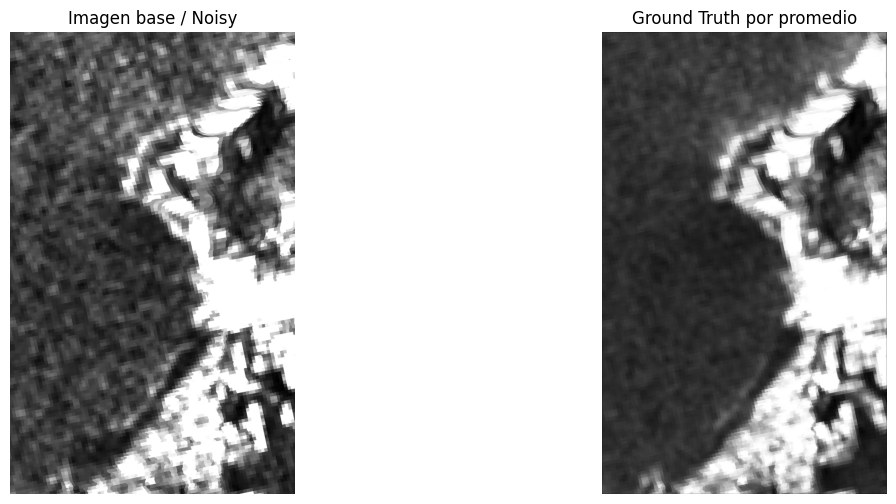

In [17]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(ref_img, cmap="gray")
plt.title("Imagen base / Noisy")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(avgGT, cmap="gray")
plt.title("Ground Truth por promedio")
plt.axis("off")

plt.show()

In [18]:
gt_path = os.path.join(GT, "AverageGT.tiff")
cv2.imwrite(gt_path, avgGT)

noisy_base_path = os.path.join(GT, "NoisyBase.tiff")
cv2.imwrite(noisy_base_path, ref_img)

print("Ground Truth guardado en:", gt_path)
print("Imagen base noisy guardada en:", noisy_base_path)

Ground Truth guardado en: C:\Users\Sebastian-EDU\Documents\GitHub\ComputerVisionIA\CV_GuideThree\gt\AverageGT.tiff
Imagen base noisy guardada en: C:\Users\Sebastian-EDU\Documents\GitHub\ComputerVisionIA\CV_GuideThree\gt\NoisyBase.tiff


In [19]:
size = 512
step = 512

height, width = ref_img.shape[:2]

print("Shape noisy base:", ref_img.shape)
print("Shape Ground Truth:", avgGT.shape)
print("Height:", height)
print("Width:", width)
print("Size:", size)
print("Step:", step)

ys = list(range(0, height - size, step))
xs = list(range(0, width - size, step))

print("Posiciones en Y:", ys)
print("Posiciones en X:", xs)
print("Cantidad total de pares esperados:", len(ys) * len(xs))

Shape noisy base: (2500, 1541)
Shape Ground Truth: (2500, 1541)
Height: 2500
Width: 1541
Size: 512
Step: 512
Posiciones en Y: [0, 512, 1024, 1536]
Posiciones en X: [0, 512, 1024]
Cantidad total de pares esperados: 12


In [20]:
for path in glob.glob(os.path.join(NOISY, "*.tiff")):
    os.remove(path)

for path in glob.glob(os.path.join(GTRUTH, "*.tiff")):
    os.remove(path)

print("Carpetas noisy y gtruth limpiadas.")

Carpetas noisy y gtruth limpiadas.


In [21]:
counter = 0

for y in range(0, height - size, step):
    for x in range(0, width - size, step):
        noisy_crop = ref_img[y:y + size, x:x + size]
        gt_crop = avgGT[y:y + size, x:x + size]

        nombre = f"{y}_{x}.tiff"

        ruta_noisy = os.path.join(NOISY, nombre)
        ruta_gt = os.path.join(GTRUTH, nombre)

        cv2.imwrite(ruta_noisy, noisy_crop)
        cv2.imwrite(ruta_gt, gt_crop)

        counter += 1
        print(f"{counter}. Guardado par: {nombre}")

print("Total de pares generados:", counter)

1. Guardado par: 0_0.tiff
2. Guardado par: 0_512.tiff
3. Guardado par: 0_1024.tiff
4. Guardado par: 512_0.tiff
5. Guardado par: 512_512.tiff
6. Guardado par: 512_1024.tiff
7. Guardado par: 1024_0.tiff
8. Guardado par: 1024_512.tiff
9. Guardado par: 1024_1024.tiff
10. Guardado par: 1536_0.tiff
11. Guardado par: 1536_512.tiff
12. Guardado par: 1536_1024.tiff
Total de pares generados: 12


In [22]:
noisy_files = sorted(glob.glob(os.path.join(NOISY, "*.tiff")))
gtruth_files = sorted(glob.glob(os.path.join(GTRUTH, "*.tiff")))

print("Cantidad en NOISY:", len(noisy_files))
print("Cantidad en GTRUTH:", len(gtruth_files))

Cantidad en NOISY: 12
Cantidad en GTRUTH: 12


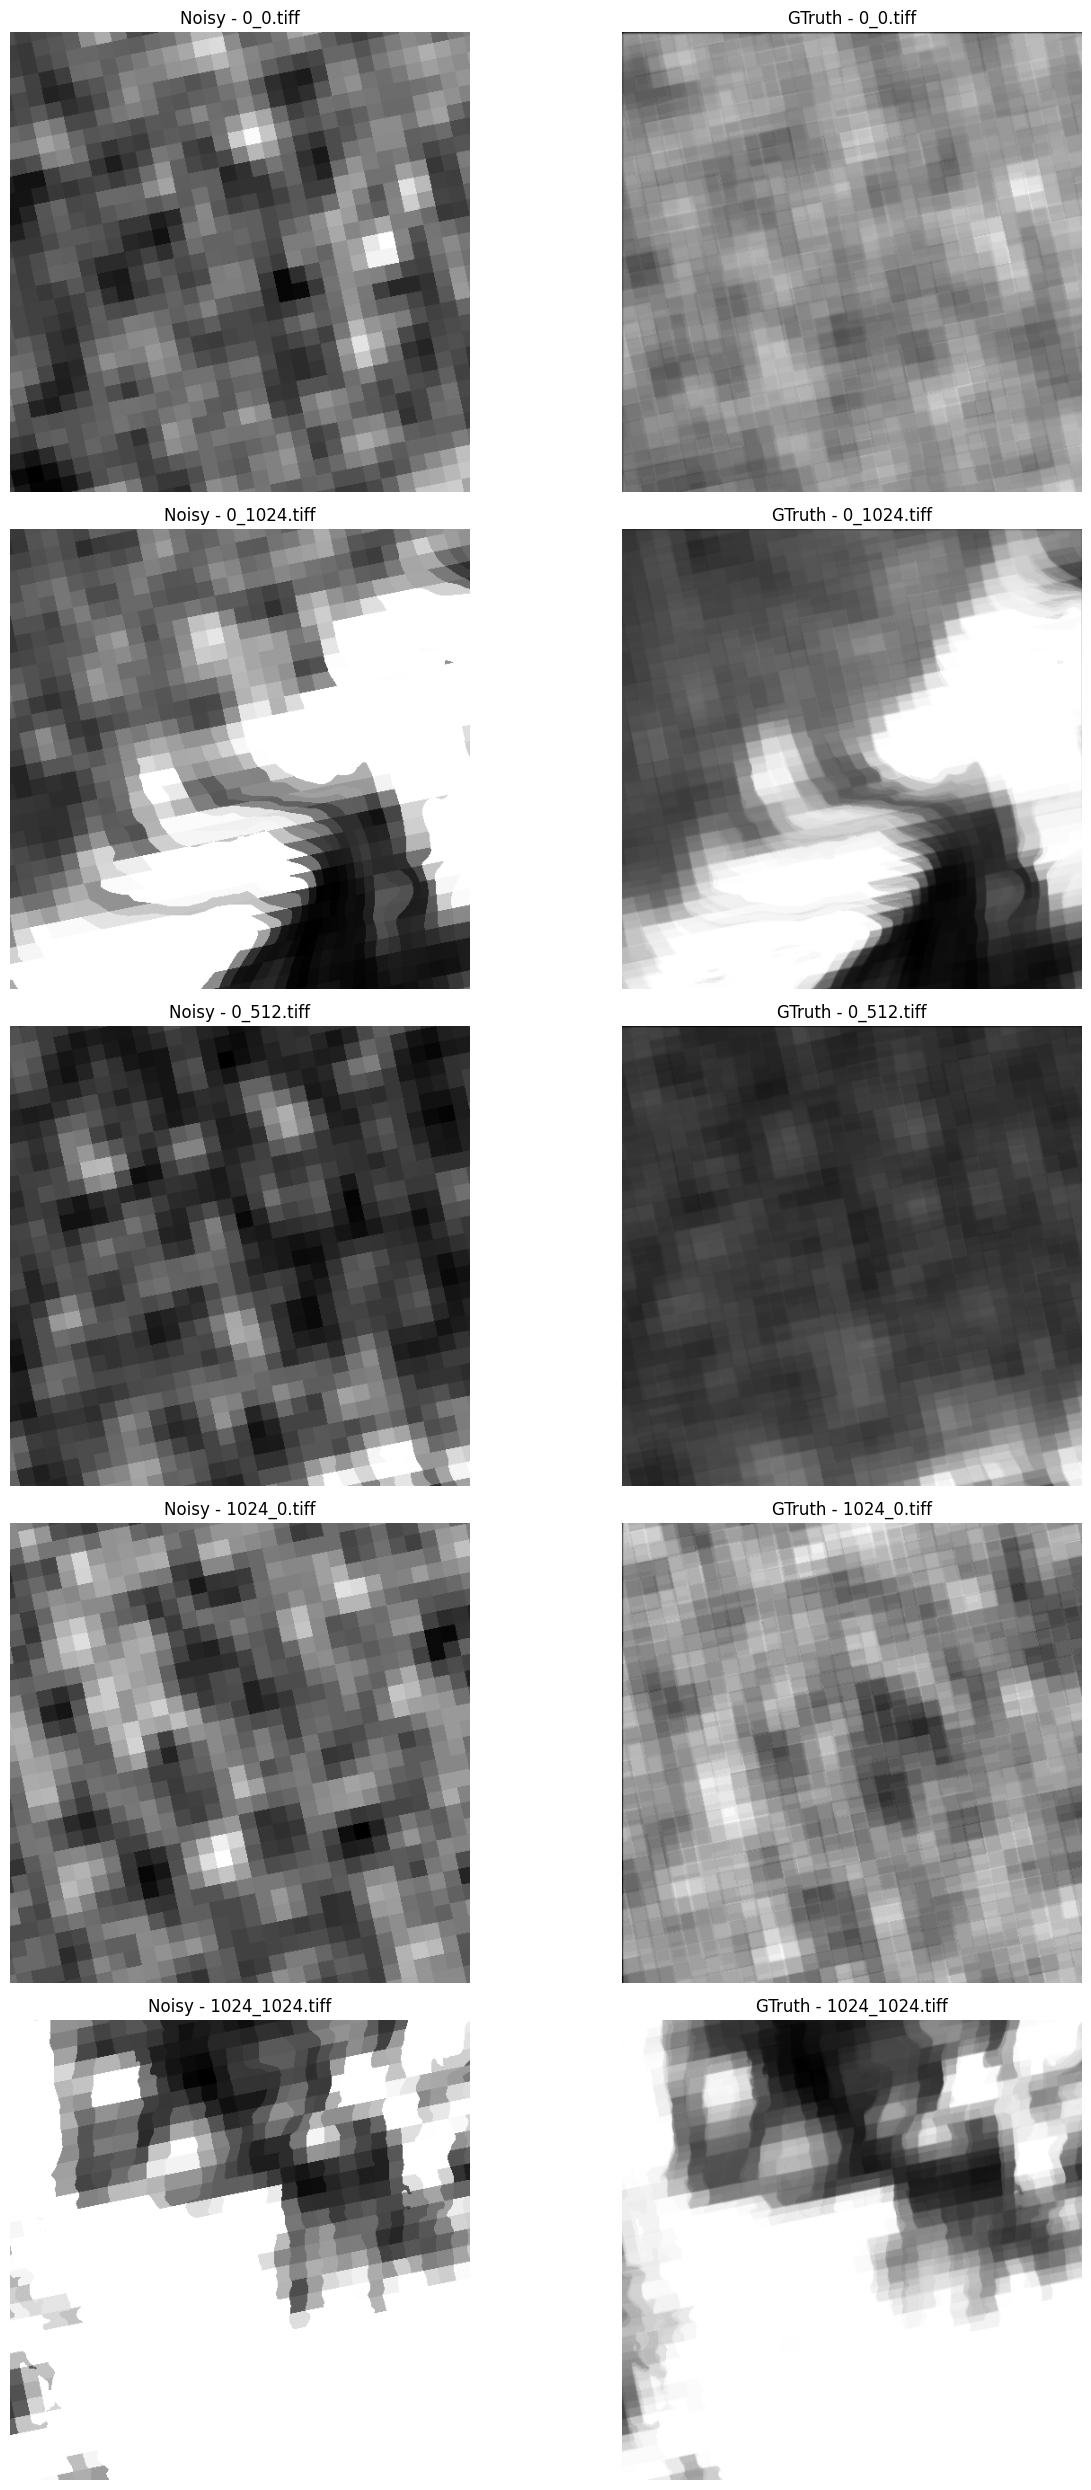

In [23]:
n = min(5, len(noisy_files))

plt.figure(figsize=(14, 5 * n))

for i in range(n):
    noisy_img = load_single_channel(noisy_files[i])
    gt_img = load_single_channel(gtruth_files[i])

    plt.subplot(n, 2, 2 * i + 1)
    plt.imshow(noisy_img, cmap="gray")
    plt.title(f"Noisy - {os.path.basename(noisy_files[i])}")
    plt.axis("off")

    plt.subplot(n, 2, 2 * i + 2)
    plt.imshow(gt_img, cmap="gray")
    plt.title(f"GTruth - {os.path.basename(gtruth_files[i])}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [24]:
df_dataset = pd.DataFrame({
    "archivo_noisy": [os.path.basename(p) for p in noisy_files],
    "archivo_gtruth": [os.path.basename(p) for p in gtruth_files]
})

csv_dataset = os.path.join(BASE, "dataset_resumen.csv")
df_dataset.to_csv(csv_dataset, index=False)

print("Resumen del dataset guardado en:")
print(csv_dataset)
df_dataset.head()

Resumen del dataset guardado en:
C:\Users\Sebastian-EDU\Documents\GitHub\ComputerVisionIA\CV_GuideThree\dataset_resumen.csv


,archivo_noisy,archivo_gtruth
0,0_0.tiff,0_0.tiff
1,0_1024.tiff,0_1024.tiff
2,0_512.tiff,0_512.tiff
3,1024_0.tiff,1024_0.tiff
4,1024_1024.tiff,1024_1024.tiff
